In [1]:
import os
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras import Input
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,classification_report,confusion_matrix

In [3]:
X_train=pd.read_csv("data/sampled/X_train_sample.csv")
X_test=pd.read_csv("data/sampled/X_test.csv")
Y_train=pd.read_csv("data/sampled/Y_train_sample.csv").squeeze()
Y_test=pd.read_csv("data/sampled/Y_test.csv").squeeze()

In [7]:
le = LabelEncoder()     #encode
Y_train = le.fit_transform(Y_train)
Y_test = le.transform(Y_test)
joblib.dump(le,"models/label_encoder.pk2")

['models/label_encoder.pk2']

In [9]:
print(X_train.shape)  #verify dataset
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(300000, 78)
(504160, 78)
(300000,)
(504160,)


In [11]:
X_train=X_train.to_numpy()  #convert to numpy
X_test=X_test.to_numpy()

In [18]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
joblib.dump(scaler, "models/lstm_scaler.pkl")

['models/lstm_scaler.pkl']

In [24]:
X_train = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_test = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])

In [26]:
model=Sequential([                            #build model
    Input(shape=(1,X_train.shape[2])),
    LSTM(128,return_sequences=True),
    Dropout(0.30),
    LSTM(63),
    Dropout(0.30),
    Dense(64,activation="relu"),
    Dense(32,activation="relu"),
    Dense(len(np.unique(Y_train)),activation="softmax")
])

In [28]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [30]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

In [34]:
checkpoint=ModelCheckpoint(
    "models/lstm2.keras",
    monitor="val_accuracy",
    save_best_only=True
)

In [36]:
start_train = time.time()
history = model.fit(
    X_train,
    Y_train,
    epochs=40,
    batch_size=256,
    validation_split=0.2,
    callbacks=[early_stop, checkpoint],
    verbose=1

)

end_train = time.time()
training_time = end_train - start_train
print(f"Training Time: {training_time:.2f} seconds")

Epoch 1/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.9433 - loss: 0.2496 - val_accuracy: 0.9695 - val_loss: 0.0885
Epoch 2/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9673 - loss: 0.0844 - val_accuracy: 0.9728 - val_loss: 0.0699
Epoch 3/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9732 - loss: 0.0674 - val_accuracy: 0.9762 - val_loss: 0.0579
Epoch 4/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9760 - loss: 0.0588 - val_accuracy: 0.9757 - val_loss: 0.0535
Epoch 5/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.9774 - loss: 0.0540 - val_accuracy: 0.9813 - val_loss: 0.0477
Epoch 6/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9789 - loss: 0.0508 - val_accuracy: 0.9809 - val_loss: 0.0460
Epoch 7/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.9793 - loss: 0.0493 - val_accuracy: 0.9819 - val_loss: 0.0439
Epoch 8/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.9798 - loss: 0.0477 - 

In [38]:
model=load_model("models/lstm2.keras")

In [40]:
start_predict=time.time()
prob=model.predict(X_test)                   #prediction
Y_pred=np.argmax(prob,axis=1)
end_predict=time.time()
prediction_time=end_predict-start_predict
print(f"Prediction Time: {prediction_time:.2f} seconds")

15755/15755 ━━━━━━━━━━━━━━━━━━━━ 27s 2ms/step
Prediction Time: 38.73 seconds


In [42]:
accuracy = accuracy_score(Y_test, Y_pred)  #accuracy
precision = precision_score(
    Y_test,
    Y_pred,
    average="weighted",
    zero_division=0
)
recall = recall_score(
    Y_test,
    Y_pred,
    average="weighted",
    zero_division=0
)
f1 = f1_score(
    Y_test,
    Y_pred,
    average="weighted",
    zero_division=0
)
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.986194858774992
Precision: 0.9854953311754697
Recall   : 0.986194858774992
F1 Score : 0.9855160643466306


In [44]:
from sklearn.metrics import balanced_accuracy_score
balanced_acc = balanced_accuracy_score(
    Y_test,
    Y_pred
)
print("Balanced Accuracy :", balanced_acc)

Balanced Accuracy : 0.600670562087952


In [46]:
print(classification_report(Y_test,Y_pred,zero_division=0))
print(confusion_matrix(Y_test,Y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99    419012
           1       0.97      0.35      0.51       390
           2       1.00      1.00      1.00     25603
           3       0.97      0.98      0.97      2057
           4       0.97      0.99      0.98     34569
           5       0.89      0.99      0.94      1046
           6       0.97      0.95      0.96      1077
           7       0.97      0.99      0.98      1186
           8       0.00      0.00      0.00         2
           9       0.00      0.00      0.00         7
          10       0.91      0.83      0.87     18139
          11       1.00      0.90      0.95       644
          12       0.60      0.04      0.08       294
          13       0.00      0.00      0.00         4
          14       0.00      0.00      0.00       130

    accuracy                           0.99    504160
   macro avg       0.68      0.60      0.61    504160
weighted avg       0.99   

In [48]:
results=pd.DataFrame({'Metric':['Accuracy','Precision','Recall','F1','Training Time(s)', 'Prediction Time(s)'],'Value':[accuracy,precision,recall,f1,training_time,prediction_time]})
results.to_csv('results/lstm2_results.csv',index=False)

In [50]:
report = classification_report(
    Y_test,
    Y_pred,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).transpose()

report_df.to_csv(
    "results/lstm2_classification_report.csv"
)

In [54]:
history_df = pd.DataFrame(
    history.history
)

history_df.to_csv(
    "results/lstm2_history.csv",
    index=False
)

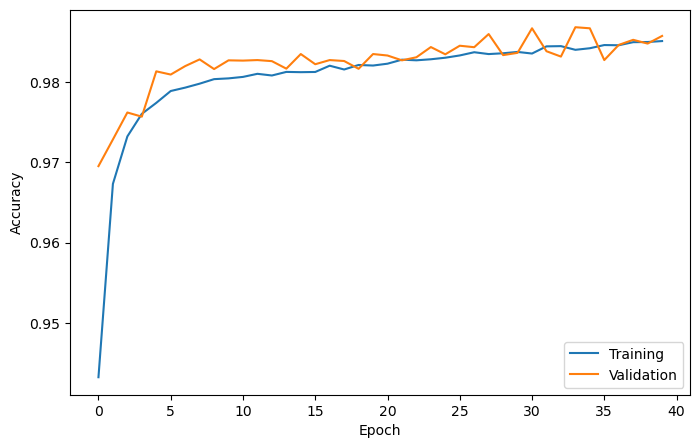

In [56]:
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.legend([
    "Training",
    "Validation"
])
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.savefig("plots/lstm2_accuracy.png")
plt.show()

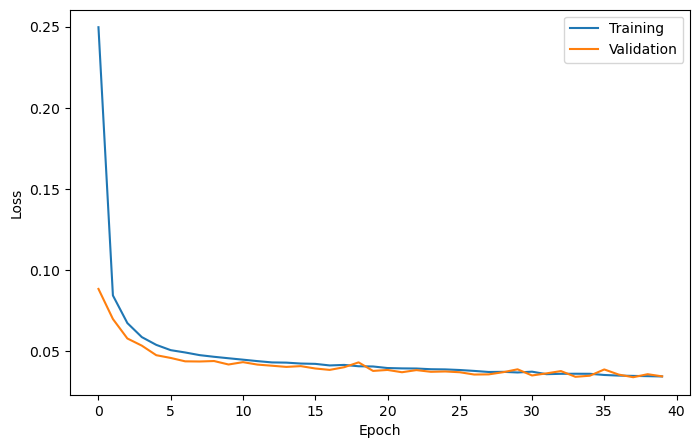

In [58]:
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.legend([
    "Training",
    "Validation"
])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.savefig("plots/lstm2_loss.png")
plt.show()